# Import libraries

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm import tqdm
import librosa
import os
from collections import defaultdict
from pydub import AudioSegment
import soundfile as sf

# Load metadata

In [7]:
df = pd.read_csv("../data/raw/thai-central/thai-central_mapping.csv")

# Data statistics

In [8]:
# Count records per speaker
speaker_counts = df['speaker_id'].value_counts()
speakers_over_100 = set(speaker_counts[speaker_counts > 100].index)

# Total number of unique speakers
total_speakers = len(speaker_counts)
print(f"Total number of unique speakers: {total_speakers}")

Total number of unique speakers: 6713


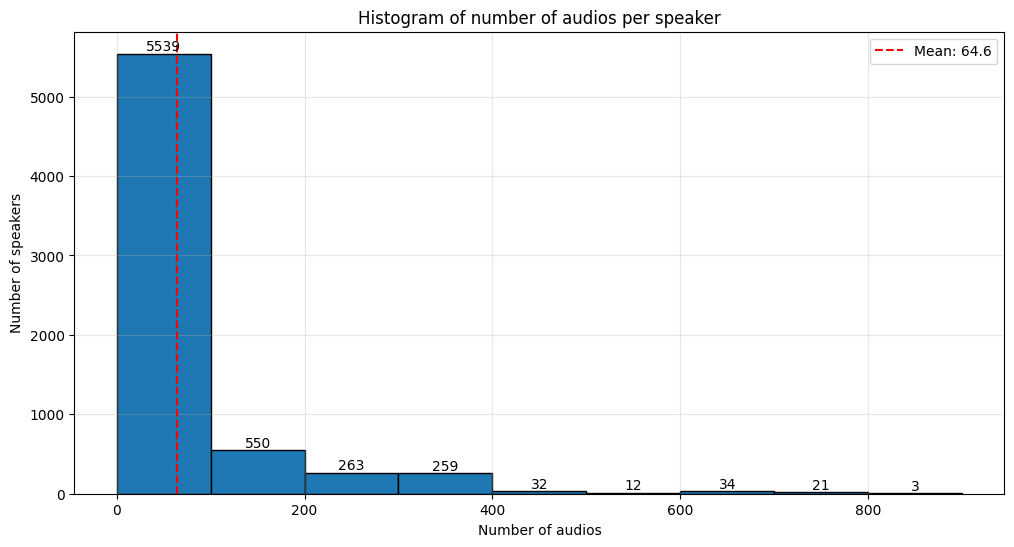

Number of speakers with over 100 records: 1165


In [9]:
plt.figure(figsize=(12, 6))
counts, bins, _ = plt.hist(speaker_counts.values, bins=range(0, max(speaker_counts) + 100, 100), 
            edgecolor='black')

# Add count labels on top of each bar
for i, count in enumerate(counts):
    if count > 0:  # Only show labels for bars with data
        plt.text(bins[i] + 50, count, str(int(count)), 
                ha='center', va='bottom')

# Add mean vertical line
mean_value = speaker_counts.mean()
plt.axvline(x=mean_value, color='r', linestyle='--', label=f'Mean: {mean_value:.1f}')
plt.legend()

plt.title('Histogram of number of audios per speaker')
plt.xlabel('Number of audios')
plt.ylabel('Number of speakers')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Number of speakers with over 100 records: {len(speakers_over_100)}")

In [10]:
def get_duration(audio_path):
    """Get audio duration using soundfile"""
    with sf.SoundFile(audio_path) as f:
        return f.frames / f.samplerate

# Initialize duration counters
total_duration = 0
duration_over_100 = 0

# Create a dictionary to store durations per speaker
speaker_durations = defaultdict(float)
audio_base_dir = "../data/raw/thai-central/audio_v2"

# Create error log file
error_log = "error_files.txt"

# Initialize error counters
error_counts = {
    "file_not_found": 0,
    "other": 0
}

# Process each audio file
print("Processing audio files...")
with open(error_log, 'w') as error_file:
    error_file.write("Error Type | File Path | Error Message\n")
    error_file.write("-" * 80 + "\n")
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        speaker_id = row['speaker_id']
        audio_path = os.path.join(audio_base_dir, row['public_name'])
        
        # Check if file exists first
        if not os.path.exists(audio_path):
            error_type = "file_not_found"
            error_counts[error_type] += 1
            error_file.write(f"{error_type} | {audio_path} | File does not exist\n")
            continue
        
        try:
            # Get duration using selected method
            duration = get_duration(audio_path)
            
            # Add to total duration
            total_duration += duration

            # If speaker has over 100 records, add to duration
            if speaker_id in speakers_over_100:
                duration_over_100 += duration
            
        except Exception as e:
            error_type = "other"
            error_counts[error_type] += 1
            error_file.write(f"{error_type} | {audio_path} | {str(e)}\n")
            continue

# Convert to hours
total_hours = total_duration / 3600
duration_over_100_hours = duration_over_100 / 3600

print(f"\nDuration Analysis:")
print(f"Total duration: {total_hours:.2f} hours ({total_duration:.2f} seconds)")
print(f"Total duration for speakers with over 100 records: {duration_over_100_hours:.2f} hours ({duration_over_100:.2f} seconds)")

# Print error statistics
print(f"\nError Statistics:")
print(f"File not found errors: {error_counts['file_not_found']}")
print(f"Other errors: {error_counts['other']}")
print(f"Total errors: {sum(error_counts.values())}")
print(f"\nDetailed error information has been saved to: {error_log}")

Processing audio files...


100%|██████████| 433814/433814 [00:41<00:00, 10456.17it/s]


Duration Analysis:
Total duration: 708.01 hours (2548852.68 seconds)
Total duration for speakers with over 100 records: 488.99 hours (1760367.14 seconds)

Error Statistics:
File not found errors: 92675
Other errors: 0
Total errors: 92675

Detailed error information has been saved to: error_files.txt
